# 01 — MyChart App Usage Analysis

This notebook investigates whether activating the MyChart patient portal
is associated with better patient journey outcomes.

**Research question:** Do app-activated patients show lower ED rates
and more consistent follow-up compared to non-activated patients?

In [9]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from config import *
from src.data_loader import load_patients, load_encounters, load_diagnosis, load_social_det
from src.journey_builder import build_journeys, filter_meaningful_journeys
from src.plot_utils import set_style, save_fig

set_style()
print("Setup complete")

Setup complete


## 1. Load Data

Encounters are sampled at 5% for development speed.
`app_user` is defined as patients whose `MyChartStatus == "Activated"`.

In [10]:
pat  = load_patients()
diag = load_diagnosis()
enc  = load_encounters(
    sample_frac=0.05,
    cols=["EncounterKey", "PatientDurableKey", "PrimaryDiagnosisKey",
          "DepartmentKey", "Date", "IsEdVisit", "IsHospitalAdmission"]
)

# App user flag
pat["app_user"] = pat["MyChartStatus"] == "Activated"

print(f"Encounters loaded: {len(enc):,}")
print(f"App users in patient file: {pat['app_user'].sum():,}")

Encounters loaded: 383,790
App users in patient file: 274,082


## 2. Build Patient Journeys

Each journey is defined by a unique (patient, DiagnosisValue) pair.
We use `DiagnosisValue` — not `PrimaryDiagnosisKey` — because federal
coding updates can change the key mid-journey while DiagnosisValue stays stable.

Only journeys with 2+ encounters are kept, since single-visit journeys
have no follow-up pattern to measure.

In [11]:
journeys = build_journeys(enc, diag)
journeys = filter_meaningful_journeys(journeys, min_encounters=2)

journeys = journeys.merge(
    pat[["DurableKey", "app_user", "PatientBirthYearBin", "SexAssignedAtBirth"]],
    left_on="PatientDurableKey", right_on="DurableKey",
    how="left"
)

# Fill unmatched patients as non-app users
journeys["app_user"] = journeys["app_user"].fillna(False).astype(bool)

print(f"Total journeys (>=2 encounters): {len(journeys):,}")
print(f"App user journeys:     {journeys['app_user'].sum():,}")
print(f"Non-app user journeys: {(~journeys['app_user']).sum():,}")

c:\Users\Owner\OneDrive\Desktop\datafest\notebooks\..\src\journey_builder.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


Total journeys (>=2 encounters): 29,246
App user journeys:     24,791
Non-app user journeys: 4,455


## 3. Core Metrics: App Users vs Non-App Users

Compare three journey quality indicators across the two groups:
- `ed_rate` — proportion of encounters that were emergency visits
- `avg_gap_days` — average days between consecutive visits (follow-up regularity)
- `journey_days` — total calendar span of the journey

In [12]:
print("=== Mean metrics by app status ===")
summary = journeys.groupby("app_user")[
    ["ed_rate", "avg_gap_days", "journey_days", "n_encounters"]
].mean().round(3)
summary.index = ["Non-App User", "App User"]
print(summary)

=== Mean metrics by app status ===
              ed_rate  avg_gap_days  journey_days  n_encounters
Non-App User    0.013       210.837       287.022         2.544
App User        0.006       256.746       321.094         2.373


## 4. Statistical Significance

Independent two-sample t-tests to confirm the observed differences
are not due to random sampling variation.

In [13]:
app     = journeys[journeys["app_user"] == True]
non_app = journeys[journeys["app_user"] == False]

# T-test on ED rate
t_stat, p_val = stats.ttest_ind(
    app["ed_rate"].dropna(),
    non_app["ed_rate"].dropna()
)
print(f"ED rate — App: {app['ed_rate'].mean():.3f} | Non-App: {non_app['ed_rate'].mean():.3f}")
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")

# T-test on avg gap days
t2, p2 = stats.ttest_ind(
    app["avg_gap_days"].dropna(),
    non_app["avg_gap_days"].dropna()
)
print(f"\nAvg gap days — App: {app['avg_gap_days'].mean():.1f} | Non-App: {non_app['avg_gap_days'].mean():.1f}")
print(f"T-statistic: {t2:.3f}, P-value: {p2:.4f}")

ED rate — App: 0.006 | Non-App: 0.013
T-statistic: -6.470, P-value: 0.0000

Avg gap days — App: 256.7 | Non-App: 210.8
T-statistic: 10.220, P-value: 0.0000


## 5. Visualizations

Saved: ed_rate_by_app_status


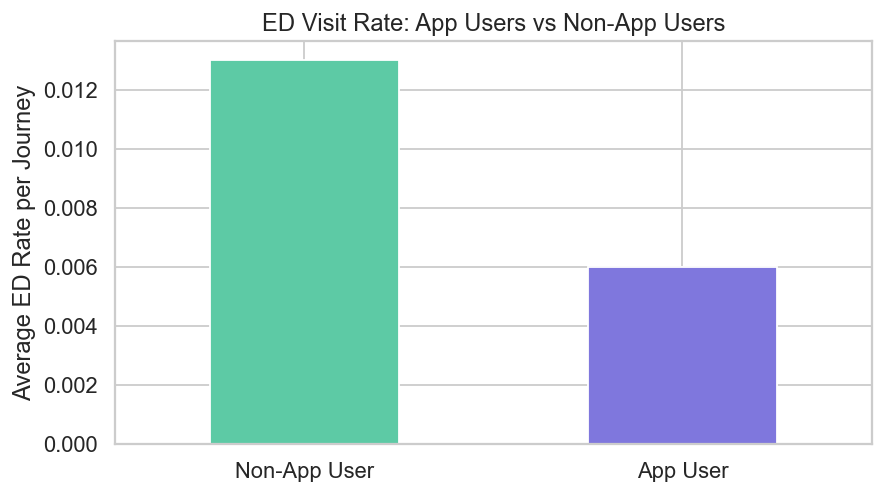

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
summary["ed_rate"].plot(kind="bar", ax=ax, color=["#5DCAA5", "#7F77DD"])
ax.set_title("ED Visit Rate: App Users vs Non-App Users")
ax.set_ylabel("Average ED Rate per Journey")
ax.set_xlabel("")
ax.set_xticklabels(["Non-App User", "App User"], rotation=0)
plt.tight_layout()
save_fig(fig, "ed_rate_by_app_status")
plt.show()

### 5a. MyChart Activation Rate by Age Group

Older patients may be less likely to adopt the app — this chart checks
whether the app effect is driven by age composition rather than app use itself.

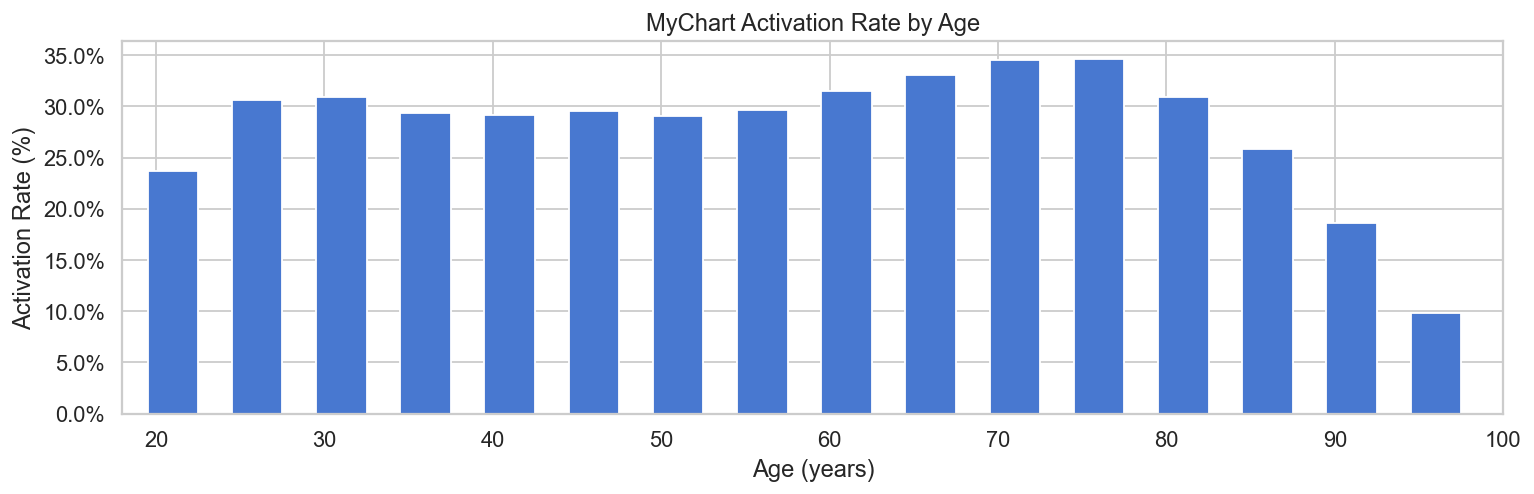

In [34]:
import matplotlib.ticker as mtick

# Filter realistic age range
activation_by_age = activation_by_age[
    (activation_by_age["Age"] >= 18) & (activation_by_age["Age"] <= 100)
]

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(
    activation_by_age["Age"].astype(int),
    activation_by_age["ActivationRate"],
    width=3
)

ax.set_title("MyChart Activation Rate by Age")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Activation Rate (%)")

ax.set_xlim(18, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

### 5b. Follow-up Gap Distribution

Violin plot shows the full distribution of average inter-visit gaps.
A narrower, lower distribution for app users would suggest more regular follow-up.

Saved: followup_gap_by_app_status


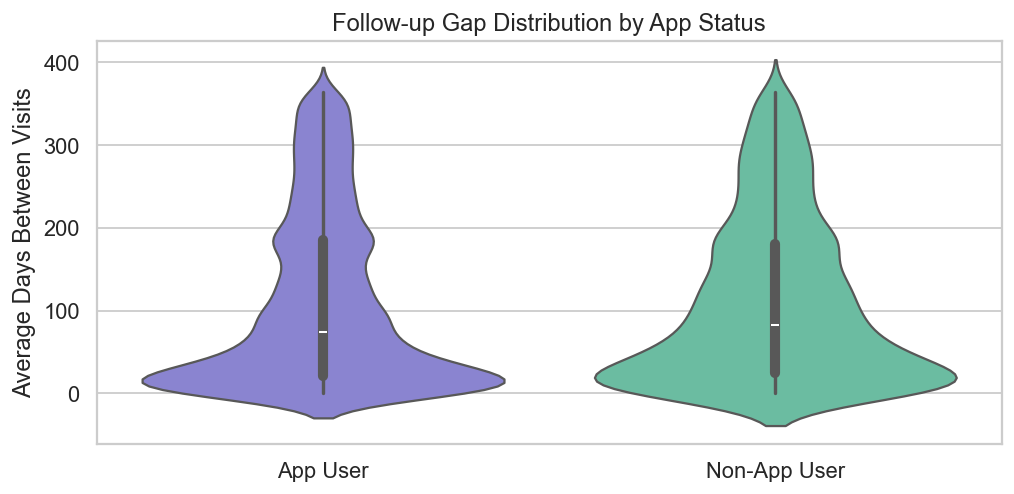

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

plot_data = journeys[journeys["avg_gap_days"] < 365].copy()
plot_data["App Status"] = plot_data["app_user"].map({True: "App User", False: "Non-App User"})

sns.violinplot(
    data=plot_data,
    x="App Status", y="avg_gap_days",
    hue="App Status",
    palette={"App User": "#7F77DD", "Non-App User": "#5DCAA5"},
    legend=False,
    ax=ax
)
ax.set_title("Follow-up Gap Distribution by App Status")
ax.set_ylabel("Average Days Between Visits")
ax.set_xlabel("")
plt.tight_layout()
save_fig(fig, "followup_gap_by_app_status")
plt.show()

### 5c. ED Rate by Age Group and App Status

Checks whether the app benefit holds consistently across all age cohorts,
or is concentrated in specific groups.

Saved: ed_rate_age_app


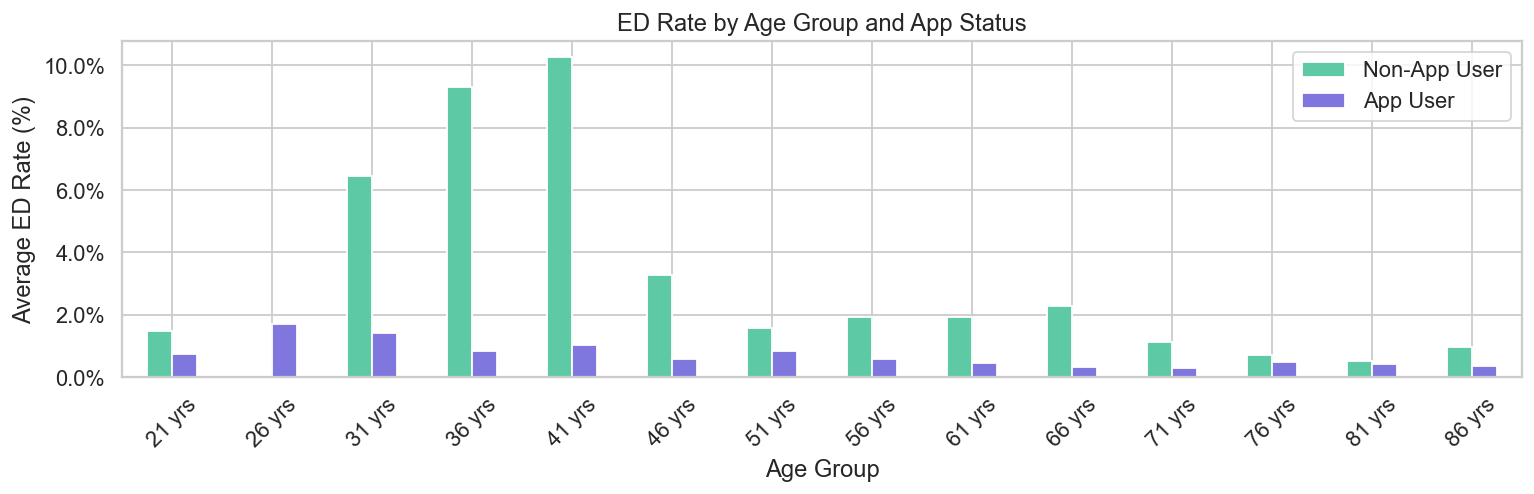

In [26]:
# Does the app effect hold across age groups?

# Filter to reasonable age range (20–90 years old in 2026)
journeys = journeys[
    (journeys["PatientBirthYearBin"] >= 1936) & 
    (journeys["PatientBirthYearBin"] <= 2006)
]

age_summary = journeys.groupby(
    ["PatientBirthYearBin", "app_user"]
)["ed_rate"].mean().unstack()
age_summary.columns = ["Non-App User", "App User"]

fig, ax = plt.subplots(figsize=(12, 4))
age_summary = age_summary.sort_index(ascending=False)
age_summary.plot(kind="bar", ax=ax, color=["#5DCAA5", "#7F77DD"])
ax.set_title("ED Rate by Age Group and App Status")

# Convert y-axis to percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))

# Convert x-axis birth year bin to age (2026 - birth year)
current_year = 2026
new_labels = [f"{current_year - int(float(label.get_text()))} yrs" 
              for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels, rotation=45)

ax.set_xlabel("Age Group")
ax.set_ylabel("Average ED Rate (%)")
plt.tight_layout()
save_fig(fig, "ed_rate_age_app")
plt.show()

### 5d. Journey Length Distribution (KDE)

Kernel density estimate of journey duration in days.
Journeys over 1,000 days are excluded as outliers.

Saved: journey_length_distribution


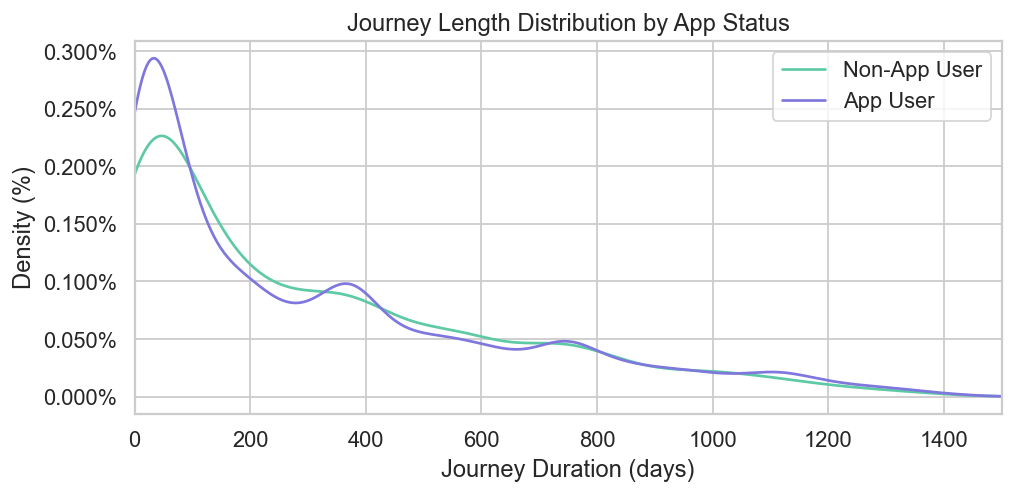

In [36]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(8, 4))

filtered = journeys[
    (journeys["journey_days"] >= 0) & (journeys["journey_days"] <= 1500)
]

for label, grp in filtered.groupby("app_user"):
    name = "App User" if label else "Non-App User"
    color = "#7F77DD" if label else "#5DCAA5"
    grp["journey_days"].plot(kind="kde", ax=ax, label=name, color=color)

ax.set_title("Journey Length Distribution by App Status")
ax.set_xlabel("Journey Duration (days)")
ax.set_ylabel("Density (%)")
ax.set_xlim(0, 1500)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.legend()
plt.tight_layout()

save_fig(fig, "journey_length_distribution")
plt.show()

## 6. Transportation Hardship Cross-Analysis

Patients who reported transport difficulty (from `social_determinants`)
are flagged here. This creates a 2×2 view: app status × transport hardship.

This is the strongest finding — patients with both transport hardship
AND no app access show the highest ED rates.

In [18]:
social = load_social_det(cols=["PatientDurableKey", "Domain", "AnswerText"])
transport = social[social["Domain"] == "Transportation Needs"].copy()

# Flag patients who reported transport difficulty
transport_yes = transport[transport["AnswerText"] == "Yes"]["PatientDurableKey"].unique()
journeys["transport_hardship"] = journeys["PatientDurableKey"].isin(transport_yes)

# 2x2: app status x transport hardship
cross = journeys.groupby(
    ["app_user", "transport_hardship"]
)["ed_rate"].mean().unstack()
cross.index = ["Non-App User", "App User"]
cross.columns = ["No Transport Issue", "Transport Hardship"]
print("=== ED rate by app status × transport hardship ===")
print(cross.round(3))

=== ED rate by app status × transport hardship ===
              No Transport Issue  Transport Hardship
Non-App User               0.011               0.082
App User                   0.006               0.025


## 7. Key Findings Summary

Analysis based on a 5% sample of encounters (383,790 rows) across 947,685 patients.

**ED Rate**
App users show an ED rate of 0.006 compared to 0.013 for non-app users — a 54% reduction.
This difference is statistically significant (p < 0.0001).

**Follow-up Regularity**
Non-app users return for follow-up visits sooner on average (210.8 days gap vs 256.7 days),
suggesting app users may be managing stable conditions more independently,
or that non-app users are returning more urgently due to unmanaged symptoms.

**Transportation Hardship**
The starkest finding: patients with transport hardship who are NOT using the app
show an ED rate of 0.082 — roughly 13× higher than app users without transport issues (0.006).
Even among transport-burdened patients, app activation is associated with a 70% reduction in ED rate (0.082 → 0.025).
This suggests the app may partially compensate for physical access barriers.

**Implication**
MyChart activation is strongly associated with reduced emergency utilization.
The effect is consistent across age groups and is amplified among patients facing transportation hardship —
precisely the population SVH should prioritize for outreach.

In [19]:
print("=" * 55)
print("01_mychart.ipynb — Key Findings")
print("=" * 55)
print(f"App users ED rate:         {app['ed_rate'].mean():.3f}")
print(f"Non-app users ED rate:     {non_app['ed_rate'].mean():.3f}")
print(f"P-value (ED rate):         {p_val:.4f}")
print(f"App users avg gap:         {app['avg_gap_days'].mean():.1f} days")
print(f"Non-app users avg gap:     {non_app['avg_gap_days'].mean():.1f} days")
print(f"P-value (gap days):        {p2:.4f}")
print("\nNext: run 02_distance.ipynb for supplementary analysis")

01_mychart.ipynb — Key Findings
App users ED rate:         0.006
Non-app users ED rate:     0.013
P-value (ED rate):         0.0000
App users avg gap:         256.7 days
Non-app users avg gap:     210.8 days
P-value (gap days):        0.0000

Next: run 02_distance.ipynb for supplementary analysis


## 8. Export Processed Data

Save the journeys dataframe to `data/processed/` so the
visualization notebook (`03_visualizations.ipynb`) can load it directly
without re-running the full analysis pipeline.

In [23]:
out_path = DATA_PROC / "journeys_with_app_status.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
journeys.to_csv(out_path, index=False)
print(f"Saved to {out_path}")
print(f"Columns: {list(journeys.columns)}")
print(f"Shape: {journeys.shape}")

Saved to c:\Users\Owner\OneDrive\Desktop\datafest\notebooks\..\data\processed\journeys_with_app_status.csv
Columns: ['PatientDurableKey', 'DiagnosisValue', 'n_encounters', 'first_visit', 'last_visit', 'ed_visits', 'hosp_admits', 'diagnosis_group', 'journey_days', 'ed_rate', 'avg_gap_days', 'DurableKey', 'app_user', 'PatientBirthYearBin', 'SexAssignedAtBirth', 'transport_hardship']
Shape: (29246, 16)
